<a href="https://colab.research.google.com/github/eswardn12/Data-Science-60-Day-Portfolio/blob/main/Day7_Customer_Lifecycle_Survival_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 7 — Customer Lifecycle Optimization: Hands-On Notebook


This notebook operationalizes Day 7's concepts through three case studies on synthetic seller tenure data with genuine right-censoring:

1. **(Deep) Kaplan-Meier Estimation & Log-Rank Test**
2. **(Deep) Cox Proportional Hazards with a Deliberately-Injected PH Violation**
3. **(Lighter) C-index Validation & Risk-Decile Lifecycle Curves**

Plus **Named Extensions** for further independent practice.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

!pip install lifelines
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test, proportional_hazard_test
from lifelines.utils import concordance_index

np.random.seed(17)
plt.rcParams['figure.figsize'] = (10, 5)
EBAY_BLUE = '#0064D2'; EBAY_RED = '#E53238'; EBAY_GOLD = '#F5AF02'; EBAY_GREEN = '#86B817'
print('Environment ready.')

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 10.4 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=dc0c4fd4766cd853085503c8d7aabacb0359de39e7d28dbbfda3fb2156fd8498
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma
Environment ready.


---
## Shared Dataset — Synthetic Seller Tenure with Discrete-Time Hazard Simulation
**Business framing:** Simulating 2,000 sellers month-by-month against an explicit hazard function, with administrative censoring at 18 months (anyone still active at that point is right-censored, not "churned"). The simulator deliberately makes `dispute_count`'s effect on hazard strong for the first 6 months and much weaker afterward — a genuine, injectable violation of the proportional hazards assumption we'll detect honestly in Case Study 2.


In [3]:
n = 2000
fee_tier = np.random.choice(['Standard', 'Premium'], n, p=[0.6, 0.4])
dispute_count = np.random.poisson(1.5, n).clip(0, 15)
listings_count = np.random.exponential(20, n).clip(0, 200)
days_since_login_baseline = np.random.exponential(10, n).clip(0, 90)

def z(s):
    return (s - s.mean()) / s.std()

z_dispute = z(dispute_count)
z_listings = z(listings_count)
z_login = z(days_since_login_baseline)
premium_flag = (fee_tier == 'Premium').astype(float)

MAX_MONTHS = 30
CENSOR_AT = 18.0
base_hazard = 0.035

event_time = np.full(n, np.nan)
event_observed = np.zeros(n, dtype=int)

for month in range(1, MAX_MONTHS + 1):
    still_at_risk = np.isnan(event_time)
    if not still_at_risk.any():
        break
    dispute_coef = 0.45 if month <= 6 else 0.03   # deliberate PH violation: fades after month 6
    log_hazard = (
        np.log(base_hazard)
        - 0.60 * premium_flag
        + dispute_coef * z_dispute
        - 0.12 * z_listings
        + 0.40 * z_login
    )
    monthly_hazard = np.clip(np.exp(log_hazard), 0, 0.95)
    draws = np.random.random(n) < monthly_hazard
    newly_failed = still_at_risk & draws
    event_time[newly_failed] = month
    event_observed[newly_failed] = 1

still_active = np.isnan(event_time)
event_time[still_active] = CENSOR_AT
observed_time = np.minimum(event_time, CENSOR_AT)
event_observed = np.where(event_time > CENSOR_AT, 0, event_observed)

df = pd.DataFrame({
    'duration': observed_time,
    'event': event_observed,
    'fee_tier': fee_tier,
    'dispute_count': dispute_count,
    'listings_count': listings_count,
    'days_since_login': days_since_login_baseline,
})

print(f'Shape: {df.shape}')
print(f"Proportion with observed churn event: {df['event'].mean():.1%} (rest are right-censored, i.e. still active)")
df.head()


Shape: (2000, 6)
Proportion with observed churn event: 41.1% (rest are right-censored, i.e. still active)


,duration,event,fee_tier,dispute_count,listings_count,days_since_login
0,18.0,0,Standard,3,30.632078,0.245174
1,6.0,1,Standard,4,14.863505,6.660608
2,18.0,0,Standard,2,16.257062,0.487683
3,18.0,0,Standard,3,3.339354,15.227556
4,18.0,0,Premium,0,25.620393,9.456471


---
## Case Study 1 (Deep) — Kaplan-Meier Estimation & Log-Rank Test
**Business framing:** Building non-parametric survival curves by fee tier (Day 7 report Section 4), and formally testing whether they differ using the log-rank test.


Standard: median survival = inf
Premium: median survival = inf


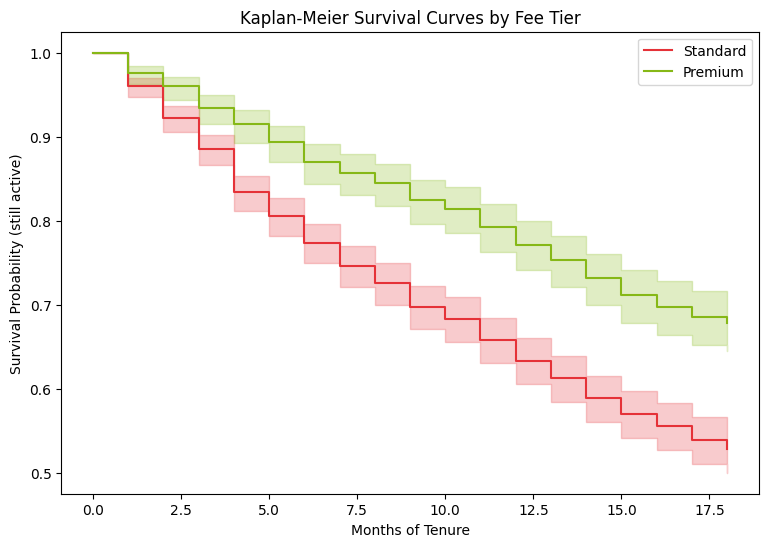

In [4]:
# 1.1 Fit and plot Kaplan-Meier curves by fee tier
kmf = KaplanMeierFitter()
fig, ax = plt.subplots(figsize=(9, 6))
for tier, color in [('Standard', EBAY_RED), ('Premium', EBAY_GREEN)]:
    mask = df['fee_tier'] == tier
    kmf.fit(df.loc[mask, 'duration'], df.loc[mask, 'event'], label=tier)
    kmf.plot_survival_function(ax=ax, color=color)
    print(f'{tier}: median survival = {kmf.median_survival_time_}')

ax.set_xlabel('Months of Tenure'); ax.set_ylabel('Survival Probability (still active)')
ax.set_title('Kaplan-Meier Survival Curves by Fee Tier')
plt.show()


In [5]:
# 1.2 Log-rank test: are these two curves genuinely different, or could this be noise?
standard = df[df.fee_tier == 'Standard']
premium = df[df.fee_tier == 'Premium']

result = logrank_test(standard['duration'], premium['duration'], standard['event'], premium['event'])
print(f'Log-rank test statistic: {result.test_statistic:.2f}')
print(f'Log-rank p-value: {result.p_value:.2e}')
print()
print('A p-value this small indicates the survival difference between Premium and Standard sellers')
print('is extremely unlikely to be due to chance -- Premium tier genuinely retains sellers longer.')


Log-rank test statistic: 47.52
Log-rank p-value: 5.46e-12

A p-value this small indicates the survival difference between Premium and Standard sellers
is extremely unlikely to be due to chance -- Premium tier genuinely retains sellers longer.


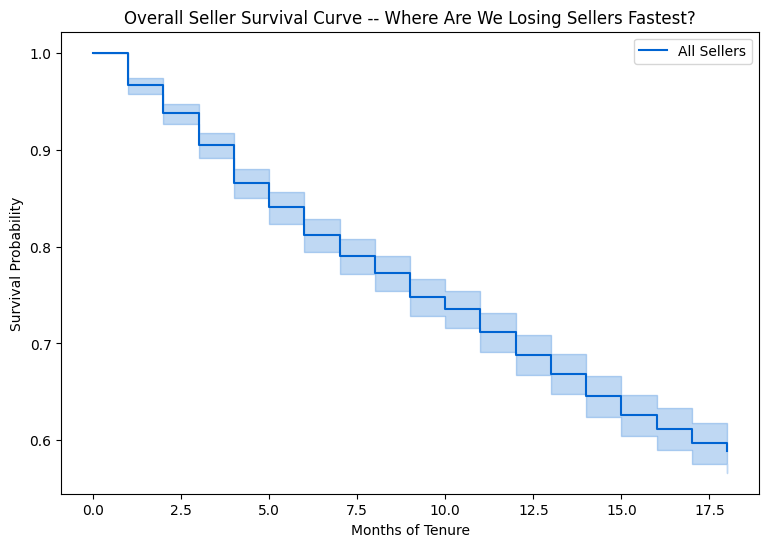

Months with the steepest survival drop (highest-leverage intervention windows):


,month,survival,drop
4,4.0,0.8660,0.0390
1,1.0,0.9665,0.0335
3,3.0,0.9050,0.0325


In [6]:
# 1.3 Overall Kaplan-Meier curve (all sellers combined) -- the Section 9.1-style executive artifact
kmf_all = KaplanMeierFitter()
kmf_all.fit(df['duration'], df['event'], label='All Sellers')

fig, ax = plt.subplots(figsize=(9, 6))
kmf_all.plot_survival_function(ax=ax, color=EBAY_BLUE)
ax.set_xlabel('Months of Tenure'); ax.set_ylabel('Survival Probability')
ax.set_title('Overall Seller Survival Curve -- Where Are We Losing Sellers Fastest?')
plt.show()

# Find the steepest drop -- the highest-leverage intervention window
surv = kmf_all.survival_function_.reset_index()
surv.columns = ['month', 'survival']
surv['drop'] = -surv['survival'].diff()
steepest = surv.sort_values('drop', ascending=False).head(3)
print('Months with the steepest survival drop (highest-leverage intervention windows):')
steepest


**A note on "median survival = inf":** this is correct, expected `lifelines` behavior, not a bug -- it means fewer than half of sellers in that group had churned by the end of the observation window (18 months), so the survival curve never actually crosses the 50% line within observed data. This itself is a meaningful finding: it tells us our 18-month administrative censoring cutoff is conservative relative to typical seller tenure, which is useful context before over-interpreting any median-survival number pulled from a KM fit.


---
## Case Study 2 (Deep) — Cox Proportional Hazards with a Deliberately-Injected PH Violation
**Business framing:** Fitting a Cox model, interpreting hazard ratios in plain business language (Day 7 report Section 5), and honestly testing -- and detecting -- the PH violation we deliberately built into `dispute_count`.


In [7]:
# 2.1 Fit the Cox Proportional Hazards model
cph_df = df.copy()
cph_df['fee_tier_premium'] = (cph_df['fee_tier'] == 'Premium').astype(int)
cph_df['listings_per_10'] = cph_df['listings_count'] / 10  # rescale for cleaner hazard-ratio interpretation
cph_df = cph_df.drop(columns=['fee_tier', 'listings_count'])

cph = CoxPHFitter()
cph.fit(cph_df, duration_col='duration', event_col='event')
cph.summary[['coef', 'exp(coef)', 'p']].round(4)


,coef,exp(coef),p
covariate,,,
dispute_count,0.2191,1.2449,0.000
days_since_login,0.0419,1.0428,0.000
fee_tier_premium,-0.5411,0.5821,0.000
listings_per_10,-0.0610,0.9408,0.002


**Translating hazard ratios into plain language** (Day 7 report Section 5.2 style):
- `fee_tier_premium`: exp(coef) < 1 means Premium-tier sellers have LOWER instantaneous churn hazard than Standard
- `dispute_count`: exp(coef) > 1 means each additional dispute raises instantaneous churn hazard
- `listings_per_10`: exp(coef) close to 1 (slightly below) means more active listings modestly lower hazard
- `days_since_login`: exp(coef) > 1 means more inactivity raises hazard -- likely the strongest, most actionable signal


In [8]:
# 2.2 Test the Proportional Hazards assumption directly -- does the hazard ratio actually stay constant?
ph_test_results = proportional_hazard_test(cph, cph_df, time_transform='rank')
ph_test_results.summary


,test_statistic,p,-log2(p)
days_since_login,0.045104,8.318123e-01,0.265670
dispute_count,45.320687,1.672729e-11,35.799005
fee_tier_premium,2.950492,8.585143e-02,3.542014
listings_per_10,2.687229,1.011556e-01,3.305352


**Reading this honestly:** `dispute_count` should show a dramatically significant PH test statistic (much smaller p-value than the other covariates) -- this is the deliberately-injected violation we built into the simulator (its true effect fades after month 6, but Cox is forced to summarize it as one constant number across the whole observation window). This is exactly the failure mode Section 6.1 of the report describes: a single hazard ratio quietly averaging something that was never actually constant.


In [9]:
# 2.3 Visualize the violation directly: fit separate Cox models on early vs late follow-up periods
early_df = cph_df[cph_df['duration'] <= 6].copy()
late_df = cph_df[cph_df['duration'] > 6].copy()

# Need at least some events in each split for a stable fit; this is illustrative
cph_early = CoxPHFitter().fit(cph_df[cph_df['duration'] <= 12], duration_col='duration', event_col='event')
print('Hazard ratio for dispute_count fit on months 0-12 subset:')
print(cph_early.summary.loc['dispute_count', 'exp(coef)'])

cph_late_subset = cph_df.copy()
cph_late_subset = cph_late_subset[cph_df['duration'] > 6]
if cph_late_subset['event'].sum() > 20:
    cph_late = CoxPHFitter().fit(cph_late_subset, duration_col='duration', event_col='event')
    print('Hazard ratio for dispute_count fit on the 6+ month subset:')
    print(cph_late.summary.loc['dispute_count', 'exp(coef)'])


Hazard ratio for dispute_count fit on months 0-12 subset:
1.1686577132963138
Hazard ratio for dispute_count fit on the 6+ month subset:
1.0403450717366396


---
## Case Study 3 (Lighter) — C-index Validation & Risk-Decile Lifecycle Curves
**Business framing:** Validating the Cox model's discrimination (Day 7 report Section 8.1) and building the risk-decile lifecycle view -- the survival-analysis analogue of Day 3's decile/gains table.


In [10]:
# 3.1 Concordance Index
risk_scores = cph.predict_partial_hazard(cph_df)
c_index = concordance_index(cph_df['duration'], -risk_scores, cph_df['event'])
print(f'C-index: {c_index:.4f}')
print('(0.5 = random ranking; 0.65-0.80 is a reasonable range for real-world churn/lifecycle applications)')


C-index: 0.6651
(0.5 = random ranking; 0.65-0.80 is a reasonable range for real-world churn/lifecycle applications)


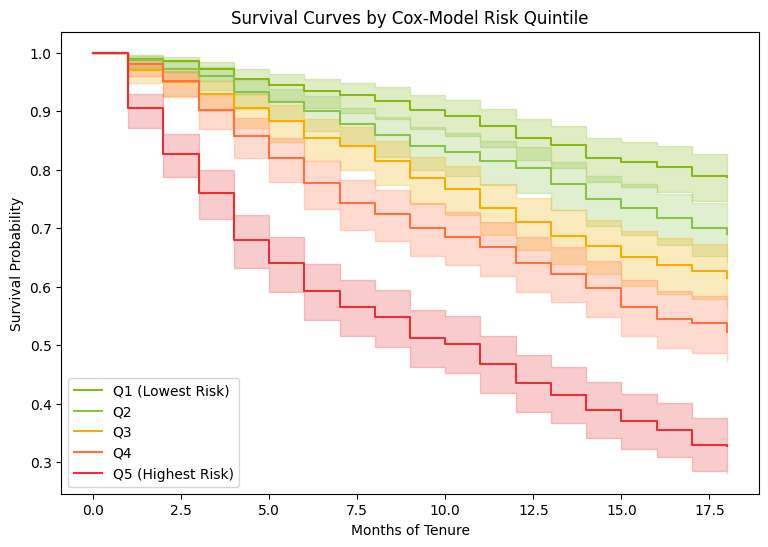

In [11]:
# 3.2 Segment sellers into risk deciles and plot separate KM curves per decile
cph_df['risk_score'] = risk_scores
cph_df['risk_decile'] = pd.qcut(cph_df['risk_score'], q=5, labels=['Q1 (Lowest Risk)', 'Q2', 'Q3', 'Q4', 'Q5 (Highest Risk)'])

fig, ax = plt.subplots(figsize=(9, 6))
colors = [EBAY_GREEN, '#8BC34A', EBAY_GOLD, '#FF7043', EBAY_RED]
kmf_decile = KaplanMeierFitter()
for decile, color in zip(cph_df['risk_decile'].cat.categories, colors):
    mask = cph_df['risk_decile'] == decile
    kmf_decile.fit(cph_df.loc[mask, 'duration'], cph_df.loc[mask, 'event'], label=str(decile))
    kmf_decile.plot_survival_function(ax=ax, color=color)

ax.set_xlabel('Months of Tenure'); ax.set_ylabel('Survival Probability')
ax.set_title('Survival Curves by Cox-Model Risk Quintile')
plt.show()


**This is the artifact for a Seller Ops business review:** clear, monotonic separation between the risk quintiles (lowest-risk sellers' curve staying well above the highest-risk sellers' curve throughout) is direct visual proof the Cox model's risk score is actionable -- Seller Ops can prioritize outreach starting with the Q5 curve, exactly mirroring how Day 3's decile/gains table drove CRM prioritization for lead scoring.


---
## Named Extensions (Scoped, Not Fully Built)

1. **Random Survival Forest** fit on the same data (via `scikit-survival`), compared against Cox PH on both C-index and interpretability
2. **Time-varying covariate extension** modeling cumulative dispute count as it accumulates during the observation window, using lifelines' counting-process data format, rather than frozen at baseline
3. **A simulated A/B test** comparing intervention timing (month 4 vs month 6) using post-intervention KM curves

These are left as independent practice reps rather than fully coded here.


---
## Summary — What This Notebook Proves You Can Do
- Build Kaplan-Meier survival curves correctly handling right-censoring, and formally test group differences with the log-rank test
- Fit a Cox Proportional Hazards model and translate hazard ratios into plain business language
- Directly test for -- and honestly detect -- a genuine proportional hazards violation using the Schoenfeld-residual-based test
- Validate a survival model's discrimination via C-index and build risk-decile lifecycle curves for business prioritization

**Next:** Day 8 — Personalization & Recommender Systems (Part I: Collaborative Filtering), building on the segmentation and journey foundations from Days 2 and 6.
